## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [1]:
# imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

### Details of input file (SDSS Spectra)

In [2]:
# exploring ..data/sdss/qso_test_spectra.fits file
hdul = fits.open(f'../data/sdss/qso_test_spectra.fits')
hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
SURVEY  = 'SDSS    '                                                            
TARGET  = 'QSO     '                                                            
DR      = '16      '                                                            
AUTHOR  = 'Abhijeet Anand'                                                      

In [3]:
hdul.close()

### Running qsoabsfind as bash script

In [4]:
# #!/bin/bash

# # Loop over absorber types
# for absorber in MgII CIV; do
#   echo "Running qsoabsfind for $absorber..."

#   qsoabsfind \
#     --input-fits-file ../data/sdss/qso_test_spectra.fits \
#     --absorber ${absorber} \
#     --output ../data/sdss/${absorber}_cat.fits \
#     --headers AUTHOR=A.Anand SURVEY=SDSS DR=16 \
#     --ncpus 8 \
#     --coldens \
#     --dv 300 \
#     --constant-file ../data/sdss/sdss_constants.py \
#     >> ../data/sdss/logs/${absorber}.log

#   echo "Finished $absorber"
# done


- I have already run `qsoabsfind` on `../data/sdss/qso_test_spectra.fits` and saved the results as `../data/sdss/MgII_cat.fits` and `../data/sdss/CIV_cat.fits`. 

### Exploring output

Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 4 extensions from ../data/sdss/MgII_cat.fits
  ABSORBER: 14 rows
  METADATA: 14 rows
  COLUMN_DENSITY: 14 rows
INFO: Time taken to read catalog from ../data/sdss/MgII_cat.fits 0.03 seconds


Text(0.5, 0, 'MgII redshift')

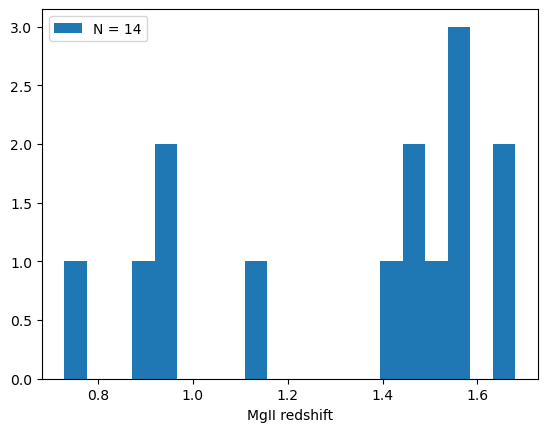

In [5]:
from qsoabsfind.spec import AbsorberData
mgii_tab = AbsorberData(f'../data/sdss/MgII_cat.fits')
mgii_tab.read_catalog()
zabs = mgii_tab.catalog["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

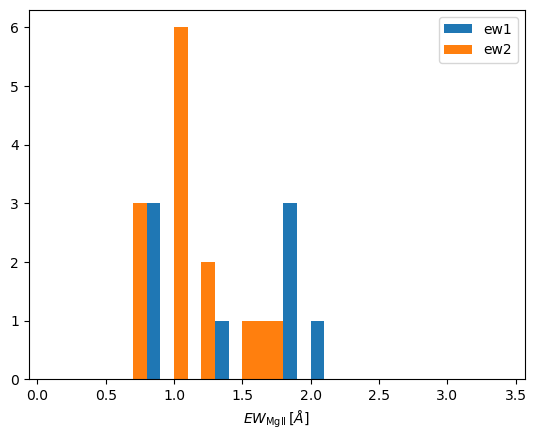

In [6]:
ew1 = mgii_tab.catalog["MGII_2796_EW"].data
ew2 = mgii_tab.catalog["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: plotting QSO INDEX = 7...
INFO: Time taken to read ../data/sdss/qso_test_spectra.fits 0.01 seconds


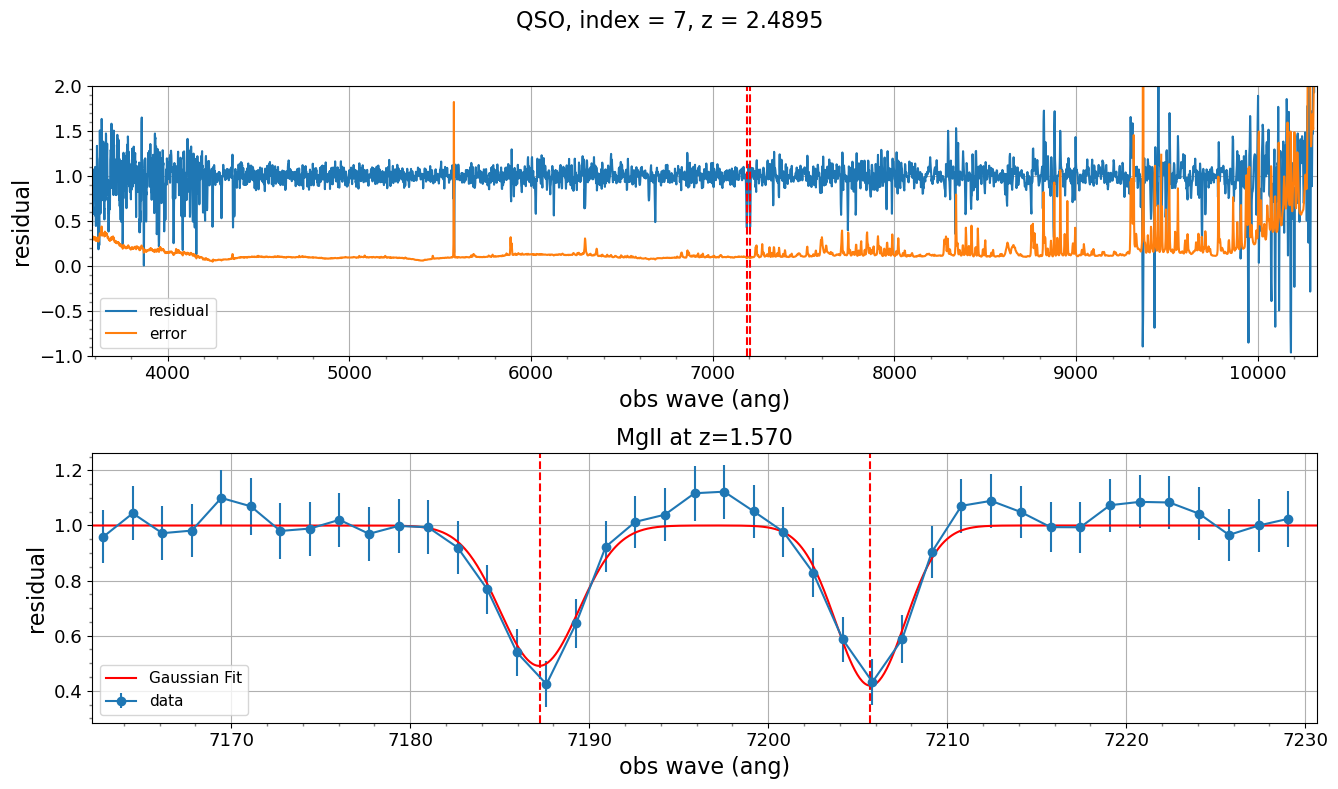

In [7]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = np.random.choice(mgii_tab.catalog["INDEX_SPEC"].data)
print(f'INFO: plotting QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/sdss/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab.catalog[mgii_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

### Using qsoabsfind internally as module

In [8]:
# if want to run qsoabsfind on one spectrum
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.config import load_constants
help(read_single_spectrum_and_find_absorber)

Help on function read_single_spectrum_and_find_absorber in module qsoabsfind.absfinder:

read_single_spectrum_and_find_absorber(fits_file, spec_index, absorber, **kwargs)
    This function retrieves a single QSO spectrum from a FITS file, processes the data to remove NaNs,
    and prepares the spectrum for absorber search within specified wavelength regions
    and runs the convolution based adaptive S/N method to detect absorbers in the spectrum.
    
    Args:
        fits_file (str): Path to the FITS file containing normalized QSO spectra.
                         The file must include extensions for FLUX, ERROR, WAVELENGTH
                         and METADATA which must contain keyword Z_QSO.
        spec_index (int): Index of the quasar spectrum to retrieve from the FITS file.
        absorber (str): Name of the absorber to search for (e.g., MgII, CIV, OVI, NV, SiIV, AlIII, FeII).
        kwargs (dict): search parameters as described in qsoabsfind.constants()
    
    Returns:
  

In [9]:
parameters = load_constants(f'../data/sdss/sdss_constants.py')
read_single_spectrum_and_find_absorber(f'../data/sdss/qso_test_spectra.fits', index, 'MgII', **parameters.search_parameters)


INFO: Starting search for QSO INDEX = 7
INFO: Time taken to read ../data/sdss/qso_test_spectra.fits 0.01 seconds
INFO: using default wavelength search window
INFO: wavelength search window in quasar-rest frame: (1549.48, 2799.117) Angstroms
INFO: final wave window selection for MgII took 0.00 seconds
INFO: search absorber = MgII
INFO: Z_QSO = 2.4894585609436035
INFO: For MgII, theoretical oscillator strength ratio: 1.999784031677045
INFO: instrumental resolution will be calculated from wavelength array, it is assumed that wavelength pixels are less than FWHM, so will not divide by 2.355
INFO: mean wave_resolution = 0.00010, mean resolution per pixel  = 68.967 [km/s], del_sigma: 0.273161882925149
INFO: convolving for kernel width: 0.8201849065133788 Angstrom.
INFO: sigma cut on convolved flux for potential candidates...
INFO: convolving for kernel width: 1.0935798753511716 Angstrom.
INFO: sigma cut on convolved flux for potential candidates...
INFO: convolving for kernel width: 1.36697

/global/homes/a/abhijeet/software/qsoabsfind/qsoabsfind/ew.py:76: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))
/global/homes/a/abhijeet/software/qsoabsfind/qsoabsfind/ew.py:76: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))
/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


INFO: performing final selection based on physical properties..
INFO: only absorbers with conf_level > 0.95 will be selected
INFO: QSO_INDEX = 7, Condition checks for Z_ABS = [0.97542501]:
INFO: gaussian_parameters > bound[0] + 0.001: [1.60120179e-01 2.79583352e+03 5.66382543e-01 2.00057238e-02
 2.80412000e+03 3.83194637e-01] > [2.10000000e-02 2.79575100e+03 1.74161883e-01 2.10000000e-02
 2.80292100e+03 1.74161883e-01]: False
INFO: gaussian_parameters < bound[0] - 0.001: [1.60120179e-01 2.79583352e+03 5.66382543e-01 2.00057238e-02
 2.80412000e+03 3.83194637e-01] < [1.10900000e+00 2.79694900e+03 8.29385649e+00 1.10900000e+00
 2.80411900e+03 8.29385649e+00]: False
INFO: lower_del_lam <= c1 - c0 <= upper_del_lam: 6.570000000000073 <= 8.286483057415808 <= 7.770000000000072: False
INFO: sn1 >= sn_line1: 1.6123734515529347 >= 3: False
INFO: sn2 >= sn_line2: -0.6514445125804859 >= 2: False
INFO: vel1 >=0: nan >= 0: False
INFO: vel2 >=0: nan >= 0: False
INFO: min_dr < dr < max_dr: -29.97758674

/global/homes/a/abhijeet/software/qsoabsfind/qsoabsfind/ew.py:76: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))
/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


INFO: QSO_INDEX = 7, Condition checks for Z_ABS = [1.52232854]:
INFO: gaussian_parameters > bound[0] + 0.001: [7.88291089e-02 2.79580433e+03 2.62496358e+00 2.00009662e-02
 2.80411670e+03 4.24280630e-01] > [2.10000000e-02 2.79575100e+03 1.74161883e-01 2.10000000e-02
 2.80292100e+03 1.74161883e-01]: False
INFO: gaussian_parameters < bound[0] - 0.001: [7.88291089e-02 2.79580433e+03 2.62496358e+00 2.00009662e-02
 2.80411670e+03 4.24280630e-01] < [1.10900000e+00 2.79694900e+03 8.29385649e+00 1.10900000e+00
 2.80411900e+03 8.29385649e+00]: True
INFO: lower_del_lam <= c1 - c0 <= upper_del_lam: 6.570000000000073 <= 8.312363278848352 <= 7.770000000000072: False
INFO: sn1 >= sn_line1: 1.334727542531036 >= 3: False
INFO: sn2 >= sn_line2: 0.09630198271199925 >= 2: False
INFO: vel1 >=0: 272.89338427837737 >= 0: True
INFO: vel2 >=0: nan >= 0: False
INFO: min_dr < dr < max_dr: -7.664829254150391 < 24.384044647216797 < 10.664613285827436: False
INFO: ew1_snr > 1: 9.302104949951172 > 1: True
INFO: ew2_

([7],
 [1.5702190455119727],
 [[0.5094561333792134,
   2796.3415777398086,
   0.8538473582716911,
   0.5813004181126107,
   2803.5381871381937,
   0.74986258422841]],
 [[0.06786703328529303,
   0.13664752554796825,
   0.13918772457554301,
   0.0712573777031083,
   0.11040169267878687,
   0.11253969299362059]],
 [1.090377688407898],
 [1.092627763748169],
 [2.1830055713653564],
 [0.032490797340869904],
 [0.03004476986825466],
 [0.044253136962652206],
 [8.125068416120484e-05],
 [6.920667152757534],
 [6.837358664362385],
 [60.19254555033424],
 [40.90592368844819],
 [198.6979522705078])

Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 4 extensions from ../data/sdss/CIV_cat.fits
  ABSORBER: 21 rows
  METADATA: 21 rows
  COLUMN_DENSITY: 21 rows
INFO: Time taken to read catalog from ../data/sdss/CIV_cat.fits 0.03 seconds


Text(0.5, 0, 'CIV redshift')

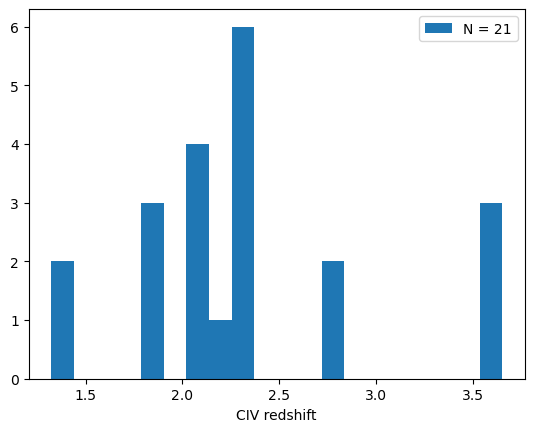

In [10]:
civ_tab = AbsorberData(f'../data/sdss/CIV_cat.fits')
civ_tab.read_catalog()
civ_zabs = civ_tab.catalog["Z_ABS"].data
plt.hist(civ_zabs, bins=20, label = f'N = {civ_zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

INFO: Time taken to read ../data/sdss/qso_test_spectra.fits 0.01 seconds
INFO: plotting CIV for QSO INDEX = 96...


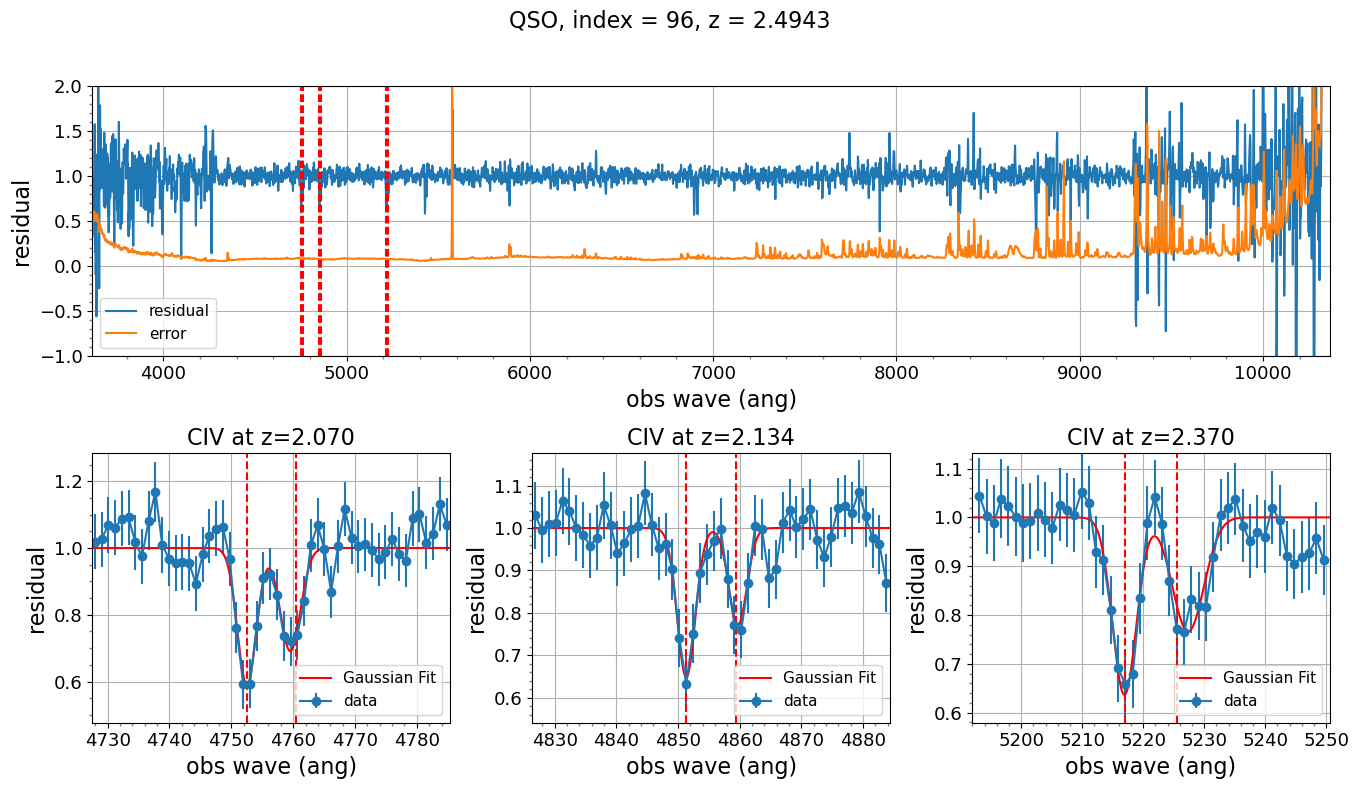

In [15]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead

# select a random spectra from CIV_cat.fits
index = np.random.choice(civ_tab.catalog["INDEX_SPEC"].data)
spectra = QSOSpecRead(f'../data/sdss/qso_test_spectra.fits', index=index, autoload=True)
print(f'INFO: plotting CIV for QSO INDEX = {index}...')
# select corresponding zabs table
zabs = civ_tab.catalog[civ_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'CIV', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)